# Pairs Trading with Spread Residual and Cycle Analysis

Pairs trading usually starts with a spread z-score. De-Time can help separate spread trend drift from residual mean reversion. A spread that trends persistently is often a broken relative-value trade, not a cheap entry.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
pair_prices = fetch_yahoo_prices(["KO", "PEP"], start="2016-01-01", cache_dir=DATA_CACHE)
weights = pair_trading_weights(pair_prices["KO"], pair_prices["PEP"], lookback=120, entry_z=1.5, exit_z=0.25)
result = backtest_weights(pair_prices, weights, fee_bps=1.0, slippage_bps=2.0)
result.stats_frame()

,value
total_return,0.082358
cagr,0.007665
volatility,0.064502
sharpe,0.150697
max_drawdown,-0.195764
calmar,0.039152
hit_rate,0.351838
average_turnover,0.021288
average_gross_exposure,0.707887
fee_bps,1.000000


In [3]:
spread = np.log(pair_prices["KO"]) - np.log(pair_prices["PEP"])
spread_frame = decompose_one_series(spread.add(100.0), method=QUANT_METHOD, period=QUANT_PERIOD, use_log_price=False)
spread_frame[["transformed_price", "trend", "residual", "residual_z"]].tail()

,transformed_price,trend,residual,residual_z
Date,,,,
2026-05-18,99.392566,99.299185,-0.000544,0.132783
2026-05-19,99.392644,99.299255,-0.000599,0.050232
2026-05-20,99.395326,99.299325,0.146865,6.573691
2026-05-21,99.393607,99.299395,0.133593,4.711388
2026-05-22,99.391160,99.299465,0.007093,0.095920


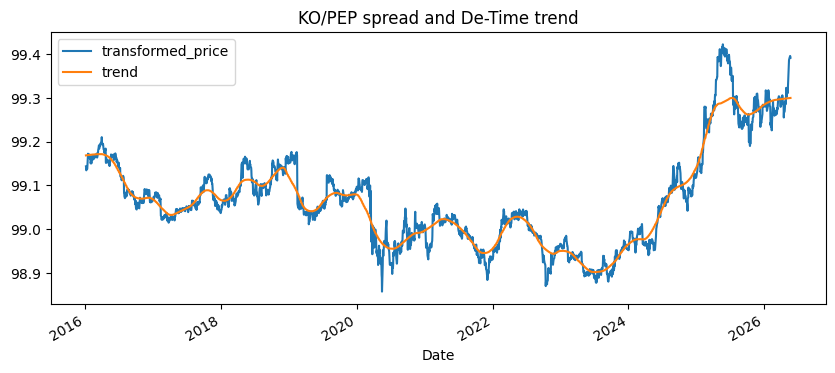

In [4]:
spread_frame[["transformed_price", "trend"]].plot(figsize=(10, 4), title="KO/PEP spread and De-Time trend")
plt.show()

## Visualization: spread residual bands and weights

Residual bands show where the pair is stretched; target weights show how the backtest responds.

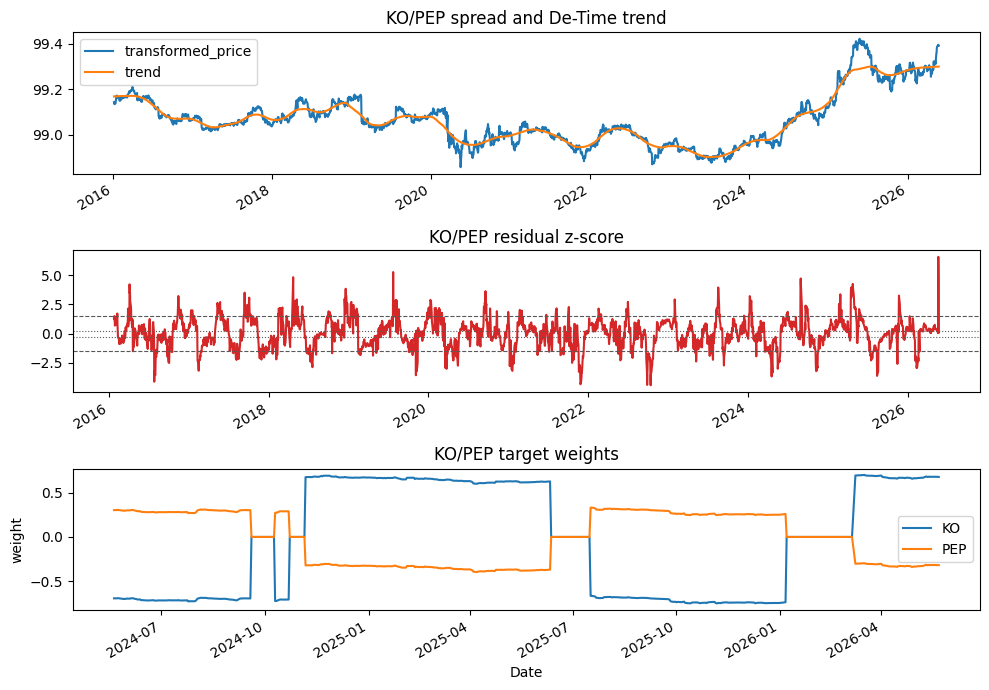

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=False)
spread_frame[["transformed_price", "trend"]].plot(ax=axes[0], title="KO/PEP spread and De-Time trend")
spread_frame["residual_z"].plot(ax=axes[1], color="tab:red", title="KO/PEP residual z-score")
for level, style in [(1.5, "--"), (-1.5, "--"), (0.25, ":"), (-0.25, ":")]:
    axes[1].axhline(level, color="0.35", linestyle=style, linewidth=0.8)
weights.tail(504).plot(ax=axes[2], title="KO/PEP target weights")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_ylabel("weight")
plt.tight_layout()
plt.show()
